<a href="https://colab.research.google.com/github/Yvesangwa/AI_labs/blob/main/Lesson_13_GenAI/Assignment_13_Generative_AI_Essentials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 13: Generative AI Essentials**

# **By Yves Sangwa**

# **Generative AI: Text Generation Using GPT**

## **Project Objective**

This project explores the fundamental concepts and practical applications of
Generative Artificial Intelligence.
For this project, we will use the *Alice's Adventures in Wonderland* by Lewis Carroll from Project Gutenberg. The work wa done using Colab notebook.

### **1. Import libraries**

In [1]:
!pip install -q transformers datasets accelerate

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


#### **Upload the dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Data.txt to Data.txt


In [3]:
# Load the book

with open("Data.txt", "r", encoding="utf-8") as file:
    text = file.read()

print("Dataset loaded successfully.")
print("Number of characters:", len(text))
print("Number of words:", len(text.split()))

Dataset loaded successfully.
Number of characters: 163950
Number of words: 29569


In [4]:
# Examine the dataset

print(text[:1000])

The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Alice's Adventures in Wonderland

Author: Lewis Carroll


        
Release date: June 27, 2008 [eBook #11]
                Most recently updated: June 26, 2025

Language: English

Other information and formats: www.gutenberg.org/ebooks/11

Credits: Arthur DiBianca and David Widger


*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents



In [6]:
# Basic statistics

dataset_info = pd.DataFrame({
    "Metric": [
        "Total Characters",
        "Total Words",
        "Unique Words"],
    "Value": [
        len(text),
        len(text.split()),
        len(set(text.lower().split()))]})

dataset_info

,Metric,Value
0,Total Characters,163950
1,Total Words,29569
2,Unique Words,5643


In [7]:
print(text[:2000])

The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Alice's Adventures in Wonderland

Author: Lewis Carroll


        
Release date: June 27, 2008 [eBook #11]
                Most recently updated: June 26, 2025

Language: English

Other information and formats: www.gutenberg.org/ebooks/11

Credits: Arthur DiBianca and David Widger


*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents



In [8]:
# Cleaning by Starting from the first chapter of the actual story
start_marker = "CHAPTER I.\nDown the Rabbit-Hole"

start = text.find(start_marker)

if start != -1:
    text_clean = text[start:].strip()
else:
    print("Start marker not found.")
    text_clean = text.strip()

print("Original characters:", len(text))
print("Cleaned characters:", len(text_clean))

print("\nBeginning of cleaned dataset:\n")
print(text_clean[:1000])

Original characters: 163950
Cleaned characters: 162480

Beginning of cleaned dataset:

CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a White Rabbit with pink eyes ran
close by her.

There was nothing so _very_ remarkable in that; nor did Alice think it
so _very_ much out of the way to hear the Rabbit say to itself, “Oh
dear! Oh dear! I shall be late!” (when she thought it over afterwards,
it occurred to her that she ought to have wondered at this, but at the
tim

In [9]:
# Display the end

print("End of cleaned dataset:\n")
print(text_clean[-1500:])

End of cleaned dataset:

nsolicited donations from donors in such states who
approach us with offers to donate.

International donations are gratefully accepted, but we cannot make
any statements concerning tax treatment of donations received from
outside the United States. U.S. laws alone swamp our small staff.

Please check the Project Gutenberg web pages for current donation
methods and addresses. Donations are accepted in a number of other
ways including checks, online payments and credit card donations. To
donate, please visit: www.gutenberg.org/donate.

Section 5. General Information About Project Gutenberg electronic works

Professor Michael S. Hart was the originator of the Project
Gutenberg concept of a library of electronic works that could be
freely shared with anyone. For forty years, he produced and
distributed Project Gutenberg eBooks with only a loose network of
volunteer support.

Project Gutenberg eBooks are often created from several printed
editions, all of which are

In [10]:
# Look for possible Gutenberg ending markers
possible_end_markers = [
    "*** END OF THE PROJECT GUTENBERG EBOOK",
    "END OF THE PROJECT GUTENBERG EBOOK",
    "End of the Project Gutenberg EBook"]

for marker in possible_end_markers:
    position = text_clean.find(marker)
    print(marker, ":", position)

*** END OF THE PROJECT GUTENBERG EBOOK : 144019
END OF THE PROJECT GUTENBERG EBOOK : 144023
End of the Project Gutenberg EBook : -1


In [11]:
# Remove anythong after the end

end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

end = text_clean.find(end_marker)

if end != -1:
    text_clean = text_clean[:end].strip()
    print("Gutenberg footer removed.")
else:
    print("End marker not found.")

print("Final cleaned characters:", len(text_clean))

print("\nBeginning:\n")
print(text_clean[:300])

print("\nEnding:\n")
print(text_clean[-1000:])

Gutenberg footer removed.
Final cleaned characters: 144015

Beginning:

CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice


Ending:


wind, and the pool rippling to the waving of the reeds—the rattling
teacups would change to tinkling sheep-bells, and the Queen’s shrill
cries to the voice of the shepherd boy—and the sneeze of the baby, the
shriek of the Gryphon, and all the other queer noises, would change
(she knew) to the confused clamour of the busy farm-yard—while the
lowing of the cattle in the distance would take the place of the Mock
Turtle’s heavy sobs.

Lastly, she pictured to herself how this same little sister of hers
would, in the after-time, be herself a grown woman; and how she would
keep, through all her riper years, the simp

### **2. Exploring Generative Pre-trained Transformers**

#### **Load the pretrained DistilGPT-2 model**

In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "distilgpt2"

# Load tokenizer and pre-trained model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# GPT-2 does not have a default padding token
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

print("Model and tokenizer loaded successfully.")
print("Model:", model_name)
print("Vocabulary size:", len(tokenizer))

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model and tokenizer loaded successfully.
Model: distilgpt2
Vocabulary size: 50257


#### **Tokenization**

In [13]:
sample_text = "Alice was beginning to get very tired."

tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.encode(sample_text)

print("Original text:")
print(sample_text)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

print("\nDecoded text:")
print(tokenizer.decode(token_ids))

Original text:
Alice was beginning to get very tired.

Tokens:
['Alice', 'Ġwas', 'Ġbeginning', 'Ġto', 'Ġget', 'Ġvery', 'Ġtired', '.']

Token IDs:
[44484, 373, 3726, 284, 651, 845, 10032, 13]

Decoded text:
Alice was beginning to get very tired.


#### **Tokenize the whole dataset in sequences**

In [14]:
# Temporarily remove tokenizer length warning because
# the text will be divided into shorter sequences afterward.
tokenizer.model_max_length = int(1e30)

encoded_text = tokenizer.encode(
    text_clean,
    add_special_tokens=False)

print("Total number of tokens:", len(encoded_text))

Total number of tokens: 44317


#### **Tokenize the training sequence**

In [15]:
sequence_length = 128

sequences = []

for i in range(0, len(encoded_text) - sequence_length, sequence_length):
    sequence = encoded_text[i:i + sequence_length]
    sequences.append(torch.tensor(sequence, dtype=torch.long))

print("Total tokens:", len(encoded_text))
print("Number of sequences:", len(sequences))
print("Tokens per sequence:", sequence_length)

Total tokens: 44317
Number of sequences: 346
Tokens per sequence: 128


#### **Split into training and validation data**

In [16]:
from torch.utils.data import Dataset, DataLoader, random_split

class TextDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        input_ids = self.sequences[index]

        return {
            "input_ids": input_ids,
            "labels": input_ids.clone()
        }

dataset = TextDataset(sequences)

# 90% training, 10% validation
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False)

print("Training sequences:", len(train_dataset))
print("Validation sequences:", len(val_dataset))

Training sequences: 311
Validation sequences: 35


In [17]:
# Move DistilGPT-2 to your T4 GPU

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


#### **Fine-tune DistilGPT-2**

In [18]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

epochs = 3

train_losses = []
val_losses = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()
    total_train_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    total_val_loss = 0

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                labels=labels
            )

            total_val_loss += outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Training Loss: {avg_train_loss:.4f} | "
        f"Validation Loss: {avg_val_loss:.4f}")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1/3 | Training Loss: 3.2913 | Validation Loss: 3.0288
Epoch 2/3 | Training Loss: 2.8758 | Validation Loss: 2.9235
Epoch 3/3 | Training Loss: 2.6644 | Validation Loss: 2.8949


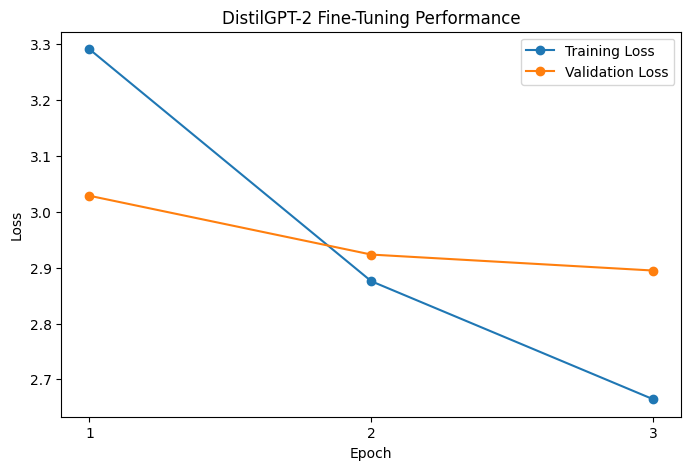

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, epochs + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilGPT-2 Fine-Tuning Performance")
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.show()

### **3. Application Demonstration**

In [20]:
# Create the Text Generation Function

def generate_text(
    seed_text,
    max_new_tokens=50,
    temperature=0.8,
    top_k=50,
    top_p=0.95
):

    inputs = tokenizer(seed_text, return_tensors="pt")
    inputs = {key: value.to(device) for key, value in inputs.items()}

    model.eval()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(
        output[0],
        skip_special_tokens=True)

#### **Basic Text Generation**

In [21]:
prompt = "Alice was beginning to"

generated_text = generate_text(
    seed_text=prompt,
    max_new_tokens=50
)

print("Prompt:")
print(prompt)

print("\nGenerated Text:")
print(generated_text)

Prompt:
Alice was beginning to

Generated Text:
Alice was beginning to doubt that
she would be invited to dinner, but she did not wish to go on without
further remarking that “it’s not only a matter of
being invited to dinner,” she was quite certain that she


#### **Controlling outout length**

In [22]:
prompt = "Alice looked at the"

lengths = [20, 50, 100]

for length in lengths:

    generated = generate_text(
        seed_text=prompt,
        max_new_tokens=length,
        temperature=0.8,
        top_k=50,
        top_p=0.95
    )

    print(f"\n--- Maximum New Tokens: {length} ---")
    print(generated)


--- Maximum New Tokens: 20 ---
Alice looked at the sky: “I’ve seen a little
little bird since I was little.�

--- Maximum New Tokens: 50 ---
Alice looked at the other side of it, and noticed a little curious
little thing in the distance, and Alice was a little curious as well, as
she had grown older, and she only had a minute to learn of the
other side of it, so

--- Maximum New Tokens: 100 ---
Alice looked at the other side of it, “then Alice was quite tired.”

“Why?” said Alice, looking at the other side of the
tree.

“It doesn’t matter if it’s a branch,” the Mock Turtle said, looking
in the direction of the Alice that seemed to follow.

“They’ll,” said the Mock Turtle, “and if they’re not,
